# Implementacion de una RNN para la prediccion del precio del Bitcoin

In [71]:
import tensorflow as tf
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

In [44]:
SEED = 42
tf.random.set_seed(SEED)

In [45]:
df = pd.DataFrame()

df = yf.download(
    "BTC-USD",
    start="2015-01-01",
    end="2024-05-04",
    interval="1d",
    auto_adjust=False
)
df = df.reset_index()

[*********************100%***********************]  1 of 1 completed


In [46]:
type(df)

pandas.core.frame.DataFrame

In [47]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2015-01-01,314.248993,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02,315.032013,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03,281.082001,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04,264.195007,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05,274.473999,274.473999,278.341003,265.084015,265.084015,43962800


In [48]:
df.tail()

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
3406,2024-04-29,63841.121094,63841.121094,64174.878906,61795.457031,63106.363281,26635912073
3407,2024-04-30,60636.855469,60636.855469,64703.332031,59120.066406,63839.417969,37840840057
3408,2024-05-01,58254.011719,58254.011719,60780.500000,56555.292969,60609.496094,48439780271
3409,2024-05-02,59123.433594,59123.433594,59602.296875,56937.203125,58253.703125,32711813559
3410,2024-05-03,62889.835938,62889.835938,63320.503906,58848.312500,59122.300781,33172023048


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3411 entries, 0 to 3410
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   (Date, )              3411 non-null   datetime64[ns]
 1   (Adj Close, BTC-USD)  3411 non-null   float64       
 2   (Close, BTC-USD)      3411 non-null   float64       
 3   (High, BTC-USD)       3411 non-null   float64       
 4   (Low, BTC-USD)        3411 non-null   float64       
 5   (Open, BTC-USD)       3411 non-null   float64       
 6   (Volume, BTC-USD)     3411 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 186.7 KB


In [50]:
df.isna().sum()

Price      Ticker 
Date                  0
Adj Close  BTC-USD    0
Close      BTC-USD    0
High       BTC-USD    0
Low        BTC-USD    0
Open       BTC-USD    0
Volume     BTC-USD    0
dtype: int64

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2024-04-24', '2024-04-25', '2024-04-26', '2024-04-27',
               '2024-04-28', '2024-04-29', '2024-04-30', '2024-05-01',
               '2024-05-02', '2024-05-03'],
              dtype='datetime64[ns]', name='Date', length=3411, freq=None)

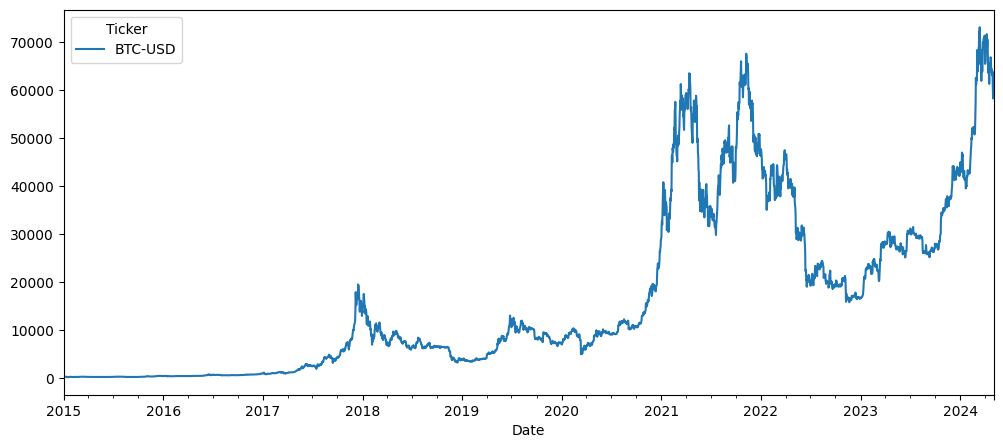

In [51]:
df=df.set_index('Date')
df['Close'].plot(figsize=(12,5))
df.index

In [52]:
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,3411.000000,3411.000000,3411.000000,3411.000000,3411.000000,3.411000e+03
mean,16556.501252,16556.501252,16925.527969,16125.033761,16539.439245,1.770204e+10
std,17873.373335,17873.373335,18286.973617,17384.075704,17860.349884,1.932928e+10
min,178.102997,178.102997,211.731003,171.509995,176.897003,7.860650e+06
25%,1471.454956,1471.454956,1483.335022,1431.589966,1437.405029,5.831630e+08
50%,9055.526367,9055.526367,9230.983398,8812.280273,9052.959961,1.373869e+10
75%,27376.728516,27376.728516,27824.029297,26872.700195,27331.023438,2.835890e+10
max,73083.500000,73083.500000,73750.070312,71334.093750,73079.375000,3.509679e+11


## Preprocesamiento del conjunto de datos

El preprocesamiento del conjunto de datos es crucial para el desarrollo de modelos de aprendizaje automático, especialmente en problemas de series temporales como la predicción del precio del Bitcoin. En esta sección, prepararemos nuestros datos para el entrenamiento de la Red Neuronal Recurrente (RNN) realizando las siguientes tareas de preprocesamiento:

1. Selección de características.
2. División de datos: Dividiremos nuestros datos en tres conjuntos: entrenamiento, validación y prueba. Ojo, realiza la separación respetando el orden temporal ya que se trata de una serie temporal.
3. Normalización: Normalizaremos los datos para que todas las características estén en la misma escala. Esto ayuda al modelo a converger más rápido durante el entrenamiento y a evitar problemas numéricos.
4. Prepara los datos en un array 3D. [batch, timesteps, feature]. Utiliza la aproximación sliding window.

In [ ]:
df = df.reset_index() # Quitamos Date como indice para que sea una columna
df = df[['Date','Close']]

In [ ]:
# No usaremos la funcion de train_tyest_split para respetar el orden temporal de los datos.

train_size = int(len(df)*0.6)
val_size = int(len(df)*0.2)
test_size = len(df) - train_size - val_size

print('Tamaño entrenamiento: ', train_size)
print('Tamaño validacion:', val_size)
print('Tamaño test:', test_size)

train_data = df[:train_size]
val_data = df[train_size:train_size+val_size]
test_data = df[train_size+val_size:]


Tamaño entrenamiento:  2046
Tamaño validacion: 682
Tamaño test: 683


In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))

X_train = scaler.fit_transform(train_data.Close)
X_val = scaler.transform(val_data.Close)
X_test = scaler.transform(test_data.Close)

In [ ]:
def create_dataset(data, time_steps):
    """
    Crea un conjunto de datos estructurado para el entrenamiento de una RNN.

    Argumentos:
    data: Array numpy, conjunto de datos de series temporales.
    time_steps: Entero, número de pasos temporales anteriores a considerar para predecir el siguiente.

    Retorna:
    X: Array numpy, conjunto de datos de características con n timesteps.
    y: Array numpy, conjunto de datos de etiquetas correspondientes a la siguiente observación después de los n timesteps.
    """
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i - time_steps:i, 0])
        y.append(data[i, 0])

    return np.expand_dims(np.array(X), axis=-1), np.array(y)

In [ ]:
WINDOW = 365 # Aplicamos una ventana de 1 año

X_train, y_train = create_dataset(X_train,WINDOW)
X_val, y_val = create_dataset(X_val,WINDOW)
X_test, y_test = create_dataset(X_test,WINDOW)

In [ ]:
X_train.shape

(1681, 365, 1)

# Entrenamiento

Se pide que se explore el entrenamiento de un modelo recurrente explorando los tipos de nueronas GRU,LST, la bidireccionalidad y las stacked RNN

## NEURONAS LSTM

In [ ]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],X_train.shape[2])))
model.add(LSTM(128))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='relu'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,873 (296.38 KB)

 Trainable params: 75,873 (296.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')
callbacks = [EarlyStopping(patience=3)]

In [ ]:
model.fit(
    X_train,y_train,
    epochs= 20,
    batch_size=32,
    callbacks = callbacks,
    validation_data=(X_val,y_val)
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - loss: 0.0101 - val_loss: 0.0889
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 0.0021 - val_loss: 0.1336
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0019 - val_loss: 0.1256
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0016 - val_loss: 0.0775
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0015 - val_loss: 0.1594
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0014 - val_loss: 0.1136
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0013 - val_loss: 0.0919


In [ ]:
print('MSE train:', model.evaluate(X_train,y_train))
print('MSE val:', model.evaluate(X_val,y_val))
print('MSE test', model.evaluate(X_test,y_test))

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 8.1805e-04
MSE train: 0.0008180525619536638
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0919
MSE val: 0.09186553210020065
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0993
MSE test 0.09934328496456146


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


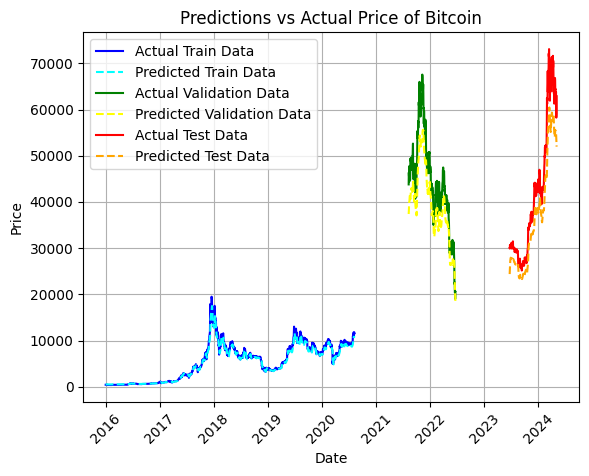

In [ ]:
y_pred_train = scaler.inverse_transform(model.predict(X_train))
y_pred_val = scaler.inverse_transform(model.predict(X_val))
y_pred_test = scaler.inverse_transform(model.predict(X_test))

# Training data
plt.plot(
    train_data['Date'][WINDOW:],
    scaler.inverse_transform(y_train.reshape(-1, 1)),
    color='blue',
    label='Actual Train Data'
)
plt.plot(
    train_data['Date'][WINDOW:],
    y_pred_train,
    color='cyan',
    linestyle='--',
    label='Predicted Train Data'
)

# Validation data
plt.plot(
    val_data['Date'][WINDOW:],
    scaler.inverse_transform(y_val.reshape(-1, 1)),
    color='green',
    label='Actual Validation Data'
)
plt.plot(
    val_data['Date'][WINDOW:],
    y_pred_val,
    color='yellow',
    linestyle='--',
    label='Predicted Validation Data'
)

# Test data
plt.plot(
    test_data['Date'][WINDOW:],
    scaler.inverse_transform(y_test.reshape(-1, 1)),
    color='red',
    label='Actual Test Data'
)
plt.plot(
    test_data['Date'][WINDOW:],
    y_pred_test,
    color='orange',
    linestyle='--',
    label='Predicted Test Data'
)

plt.title('Predictions vs Actual Price of Bitcoin')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [66]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],X_train.shape[2])))
model.add(GRU(128))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='relu'))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,617 (232.88 KB)

 Trainable params: 59,617 (232.88 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
model.compile(optimizer='adam', loss='mean_squared_error')
callbacks = [EarlyStopping(patience=3)]

In [68]:
model.fit(
    X_train,y_train,
    epochs= 20,
    batch_size=32,
    callbacks = callbacks,
    validation_data=(X_val,y_val)
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - loss: 0.0193 - val_loss: 0.1361
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0025 - val_loss: 0.1019
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0023 - val_loss: 0.0696
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 0.0018 - val_loss: 0.0589
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0018 - val_loss: 0.0480
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0015 - val_loss: 0.1423
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 0.0015 - val_loss: 0.0913
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.0012 - val_loss: 0.0746


In [69]:
print('MSE train:', model.evaluate(X_train,y_train))
print('MSE val:', model.evaluate(X_val,y_val))
print('MSE test', model.evaluate(X_test,y_test))

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.4826e-04
MSE train: 0.0005482647102326155
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0746
MSE val: 0.07457859069108963
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0799
MSE test 0.07993229478597641


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


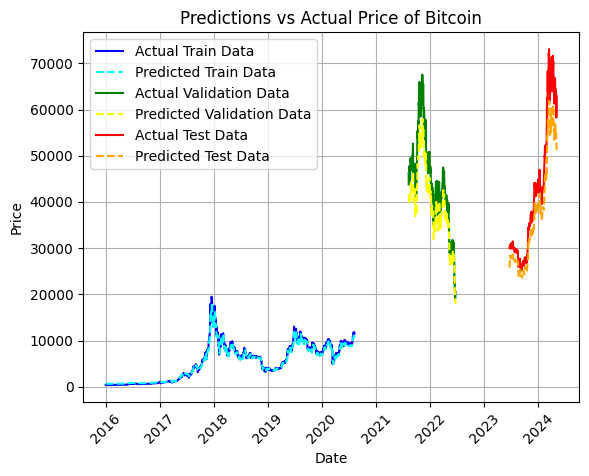

In [70]:
y_pred_train = scaler.inverse_transform(model.predict(X_train))
y_pred_val = scaler.inverse_transform(model.predict(X_val))
y_pred_test = scaler.inverse_transform(model.predict(X_test))

# Training data
plt.plot(
    train_data['Date'][WINDOW:],
    scaler.inverse_transform(y_train.reshape(-1, 1)),
    color='blue',
    label='Actual Train Data'
)
plt.plot(
    train_data['Date'][WINDOW:],
    y_pred_train,
    color='cyan',
    linestyle='--',
    label='Predicted Train Data'
)

# Validation data
plt.plot(
    val_data['Date'][WINDOW:],
    scaler.inverse_transform(y_val.reshape(-1, 1)),
    color='green',
    label='Actual Validation Data'
)
plt.plot(
    val_data['Date'][WINDOW:],
    y_pred_val,
    color='yellow',
    linestyle='--',
    label='Predicted Validation Data'
)

# Test data
plt.plot(
    test_data['Date'][WINDOW:],
    scaler.inverse_transform(y_test.reshape(-1, 1)),
    color='red',
    label='Actual Test Data'
)
plt.plot(
    test_data['Date'][WINDOW:],
    y_pred_test,
    color='orange',
    linestyle='--',
    label='Predicted Test Data'
)

plt.title('Predictions vs Actual Price of Bitcoin')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## BIDIRECCIONALIDAD

In [73]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],X_train.shape[2])))
model.add(Bidirectional(LSTM(128)))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='relu'))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 256)            │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,625 (588.38 KB)

 Trainable params: 150,625 (588.38 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
model.compile(optimizer='adam', loss='mean_squared_error')
callbacks = [EarlyStopping(patience=3)]

In [75]:
model.fit(
    X_train,y_train,
    epochs= 20,
    batch_size=32,
    callbacks = callbacks,
    validation_data=(X_val,y_val)
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0115 - val_loss: 0.0708
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0026 - val_loss: 0.0393
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0022 - val_loss: 0.0833
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - loss: 0.0022 - val_loss: 0.1462
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - loss: 0.0021 - val_loss: 0.0766


In [76]:
print('MSE train:', model.evaluate(X_train,y_train))
print('MSE val:', model.evaluate(X_val,y_val))
print('MSE test', model.evaluate(X_test,y_test))

53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 6.5952e-04
MSE train: 0.0006595191080123186
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0766
MSE val: 0.07664772868156433
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0839
MSE test 0.08387142419815063


53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


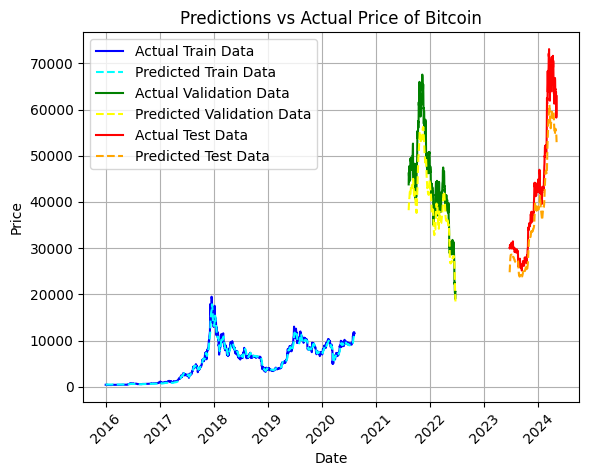

In [77]:
y_pred_train = scaler.inverse_transform(model.predict(X_train))
y_pred_val = scaler.inverse_transform(model.predict(X_val))
y_pred_test = scaler.inverse_transform(model.predict(X_test))

# Training data
plt.plot(
    train_data['Date'][WINDOW:],
    scaler.inverse_transform(y_train.reshape(-1, 1)),
    color='blue',
    label='Actual Train Data'
)
plt.plot(
    train_data['Date'][WINDOW:],
    y_pred_train,
    color='cyan',
    linestyle='--',
    label='Predicted Train Data'
)

# Validation data
plt.plot(
    val_data['Date'][WINDOW:],
    scaler.inverse_transform(y_val.reshape(-1, 1)),
    color='green',
    label='Actual Validation Data'
)
plt.plot(
    val_data['Date'][WINDOW:],
    y_pred_val,
    color='yellow',
    linestyle='--',
    label='Predicted Validation Data'
)

# Test data
plt.plot(
    test_data['Date'][WINDOW:],
    scaler.inverse_transform(y_test.reshape(-1, 1)),
    color='red',
    label='Actual Test Data'
)
plt.plot(
    test_data['Date'][WINDOW:],
    y_pred_test,
    color='orange',
    linestyle='--',
    label='Predicted Test Data'
)

plt.title('Predictions vs Actual Price of Bitcoin')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## STACKED RNN

In [78]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],X_train.shape[2])))
model.add(LSTM(128,return_sequences=True))
model.add(LSTM(64,return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='relu'))

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 365, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,025 (457.13 KB)

 Trainable params: 117,025 (457.13 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
model.compile(optimizer='adam', loss='mean_squared_error')
callbacks = [EarlyStopping(patience=3)]

In [80]:
model.fit(
    X_train,y_train,
    epochs= 20,
    batch_size=32,
    callbacks = callbacks,
    validation_data=(X_val,y_val)
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - loss: 0.0150 - val_loss: 1.1425
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - loss: 0.0026 - val_loss: 0.5942
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - loss: 0.0022 - val_loss: 0.4740
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - loss: 0.0018 - val_loss: 0.4064
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - loss: 0.0016 - val_loss: 0.4435
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - loss: 0.0016 - val_loss: 0.3893
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - loss: 0.0015 - val_loss: 0.2002
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - loss: 0.0013 - val_loss: 0.2764
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - loss: 0.0014 - val_loss: 0.3981
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - loss: 0.0012 - val_loss: 0.2236


In [81]:
print('MSE train:', model.evaluate(X_train,y_train))
print('MSE val:', model.evaluate(X_val,y_val))
print('MSE test', model.evaluate(X_test,y_test))

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 8.5619e-04
MSE train: 0.0008561929571442306
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.2236
MSE val: 0.22359536588191986
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.2523
MSE test 0.2523362338542938


53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


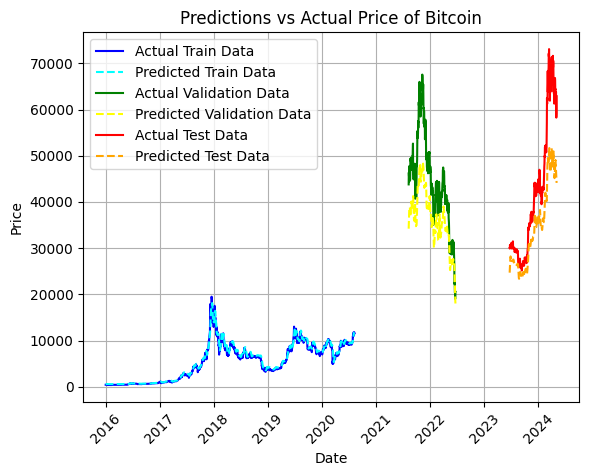

In [82]:
y_pred_train = scaler.inverse_transform(model.predict(X_train))
y_pred_val = scaler.inverse_transform(model.predict(X_val))
y_pred_test = scaler.inverse_transform(model.predict(X_test))

# Training data
plt.plot(
    train_data['Date'][WINDOW:],
    scaler.inverse_transform(y_train.reshape(-1, 1)),
    color='blue',
    label='Actual Train Data'
)
plt.plot(
    train_data['Date'][WINDOW:],
    y_pred_train,
    color='cyan',
    linestyle='--',
    label='Predicted Train Data'
)

# Validation data
plt.plot(
    val_data['Date'][WINDOW:],
    scaler.inverse_transform(y_val.reshape(-1, 1)),
    color='green',
    label='Actual Validation Data'
)
plt.plot(
    val_data['Date'][WINDOW:],
    y_pred_val,
    color='yellow',
    linestyle='--',
    label='Predicted Validation Data'
)

# Test data
plt.plot(
    test_data['Date'][WINDOW:],
    scaler.inverse_transform(y_test.reshape(-1, 1)),
    color='red',
    label='Actual Test Data'
)
plt.plot(
    test_data['Date'][WINDOW:],
    y_pred_test,
    color='orange',
    linestyle='--',
    label='Predicted Test Data'
)

plt.title('Predictions vs Actual Price of Bitcoin')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()